# Часть 4. Классификация хорошее/плохое и важность признаков

Главный вопрос: какие химические свойства определяют качество вина?

Доп. вопрос: можно ли по химическому составу заранее отделить хорошее вино от плохого?

## 0. Подготовка данных

Повторяем препроцессинг из частей 1 и 2: объединение red+white, удаление полных дубликатов, log1p скошенных признаков, удаление выбросов по правилу 3 сигма, удаление мультиколлинеарных density и total sulfur dioxide.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
os.makedirs('images', exist_ok=True)

### 0.1 Загрузка и объединение датасетов

In [2]:
red = pd.read_csv('wine_quality/winequality-red.csv', sep=';')
white = pd.read_csv('wine_quality/winequality-white.csv', sep=';')
red['type'] = 'red'
white['type'] = 'white'
wine = pd.concat([red, white], ignore_index=True)

print('Красное вино:', red.shape)
print('Белое вино:', white.shape)
print('Объединенный датасет:', wine.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'wine_quality/winequality-red.csv'

### 0.2 Удаление полных совпадений строк

In [ ]:
wine_dedup = wine.drop_duplicates().reset_index(drop=True)
print('До удаления дубликатов:', wine.shape)
print('После удаления дубликатов:', wine_dedup.shape)

До удаления дубликатов: (6497, 13)
После удаления дубликатов: (5320, 13)


### 0.3 Логарифмирование скошенных признаков

In [ ]:
wine_log = wine_dedup.copy()
cols_to_log = [
    'fixed acidity', 'volatile acidity', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'sulphates'
]
for col in cols_to_log:
    wine_log[col] = np.log1p(wine_log[col])

### 0.4 Удаление выбросов по правилу 3 сигма

In [ ]:
def three_sigma_mask(series):
    mean = series.mean()
    std = series.std()
    return (series < mean - 3 * std) | (series > mean + 3 * std)

features_for_outliers = [col for col in wine_log.columns if col not in ['quality', 'type']]
total_anomaly_mask = np.zeros(len(wine_log), dtype=bool)
for col in features_for_outliers:
    total_anomaly_mask |= three_sigma_mask(wine_log[col]).values
wine_no_outliers = wine_log.loc[~total_anomaly_mask].copy().reset_index(drop=True)

print('До удаления выбросов:', wine_log.shape)
print('После удаления выбросов:', wine_no_outliers.shape)
print('Удалено строк:', total_anomaly_mask.sum())

До удаления выбросов: (5320, 13)
После удаления выбросов: (5000, 13)
Удалено строк: 320


### 0.5 Удаление мультиколлинеарных признаков

Из части 2: density сильно коррелирует с alcohol и residual sugar (VIF около 14.6), total sulfur dioxide почти дублирует free sulfur dioxide.

In [ ]:
wine_new = wine_no_outliers.drop(columns=['density', 'total sulfur dioxide'])
print('Итоговый датасет:', wine_new.shape)

Итоговый датасет: (5000, 11)


### 0.6 Кодирование type в число

Кодируем red = 0, white = 1, чтобы использовать type как признак в моделях.

In [ ]:
wine_new['type'] = (wine_new['type'] == 'white').astype(int)
wine_new.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,pH,sulphates,alcohol,quality,type
0,2.128232,0.530628,0.00,1.064711,0.073250,2.484907,3.51,0.444686,9.4,5,0
1,2.174752,0.631272,0.00,1.280934,0.093490,3.258097,3.20,0.518794,9.8,5,0
2,2.174752,0.565314,0.04,1.193922,0.088011,2.772589,3.26,0.500775,9.8,5,0
3,2.501436,0.246860,0.56,1.064711,0.072321,2.890372,3.16,0.457425,9.8,6,0
4,2.128232,0.506818,0.00,1.029619,0.072321,2.639057,3.51,0.444686,9.4,5,0


### 0.7 Финальная проверка

In [ ]:
check = pd.DataFrame({
    'dtype': wine_new.dtypes.astype(str),
    'missing': wine_new.isna().sum(),
    'n_unique': wine_new.nunique()
})
display(check)
print('Размер итоговой выборки:', wine_new.shape)
print('Доля white:', round(wine_new['type'].mean(), 3))
wine_new['quality'].value_counts().sort_index()

,dtype,missing,n_unique
fixed acidity,float64,0,75
volatile acidity,float64,0,154
citric acid,float64,0,75
residual sugar,float64,0,310
chlorides,float64,0,138
free sulfur dioxide,float64,0,127
pH,float64,0,92
sulphates,float64,0,79
alcohol,float64,0,109
quality,int64,0,7


Размер итоговой выборки: (5000, 11)
Доля white: 0.772


quality
3      18
4     182
5    1630
6    2198
7     823
8     144
9       5
Name: count, dtype: int64

## 1. Бинаризация целевой переменной и проверка дисбаланса

По условиям проекта порог хорошего вина quality >= 7. Получаем бинарный признак is_good.

In [ ]:
wine_new['is_good'] = (wine_new['quality'] >= 7).astype(int)
class_counts = wine_new['is_good'].value_counts().sort_index()
class_share = wine_new['is_good'].value_counts(normalize=True).sort_index()
balance = pd.DataFrame({
    'count': class_counts,
    'share_%': (class_share * 100).round(2)
})
balance.index = ['плохое', 'хорошее']
balance

,count,share_%
плохое,4028,80.56
хорошее,972,19.44


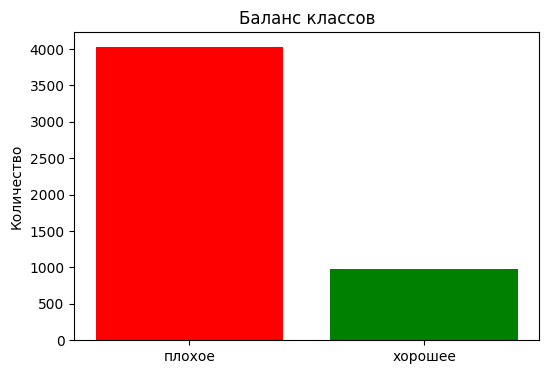

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(balance.index, balance['count'], color=['red', 'green'])
plt.title('Баланс классов')
plt.ylabel('Количество')
plt.savefig('images/class_balance.png')
plt.show()

Хороших вин около 19%, плохих 81%. Используем ROC-AUC и PR-AUC как основные метрики, в моделях ставим class_weight='balanced' для компенсации дисбаланса.

## 2. Train/test split и масштабирование

Делим выборку 80/20 со стратификацией по is_good + масштабирование

In [ ]:
feature_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'type']
X = wine_new[feature_cols].copy()
y = wine_new['is_good'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, 'доля хороших:', round(y_train.mean(), 4))
print('Test:', X_test.shape, 'доля хороших:', round(y_test.mean(), 4))

Train: (4000, 10) доля хороших: 0.1945
Test: (1000, 10) доля хороших: 0.194


In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)
X_train_scaled.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,pH,sulphates,alcohol,type
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.023,-1.890,-2.302,-1.674,-2.052,-2.935,-2.972,-2.624,-2.165,-1.817
25%,-0.652,-0.694,-0.531,-0.832,-0.707,-0.584,-0.680,-0.711,-0.900,0.550
50%,-0.160,-0.256,-0.015,-0.372,-0.283,0.161,-0.026,-0.136,-0.142,0.550
75%,0.566,0.497,0.575,0.876,0.463,0.740,0.695,0.642,0.702,0.550
max,3.353,3.233,3.156,2.584,4.840,2.616,3.117,3.389,2.936,0.550


## 3. Обучение трёх базовых моделей

- LogisticRegression - линейный baseline, коэффициенты сразу показывают направление влияния
- RandomForest - нелинейная модель, устойчивая к шкалам и мультиколлинеарности
- GradientBoosting - обычно лучший на табличных данных

Для оценки устойчивости считаем CV ROC-AUC и PR-AUC по 5 фолдам StratifiedKFold.

In [ ]:
models = {
    'LogReg': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
    )
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    auc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    ap_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    cv_rows.append({
        'model': name,
        'roc_auc_mean': auc_scores.mean().round(4),
        'roc_auc_std': auc_scores.std().round(4),
        'pr_auc_mean': ap_scores.mean().round(4),
        'pr_auc_std': ap_scores.std().round(4)
    })
cv_results = pd.DataFrame(cv_rows).set_index('model')
cv_results

,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
model,,,,
LogReg,0.8284,0.0167,0.5188,0.0389
RandomForest,0.8509,0.0167,0.5901,0.0531
GradientBoosting,0.8434,0.0170,0.5576,0.0519


In [ ]:
sample_weight_train = compute_sample_weight(class_weight='balanced', y=y_train)
fitted_models = {}
test_proba = {}
test_pred = {}
for name, model in models.items():
    if name == 'GradientBoosting':
        model.fit(X_train_scaled, y_train, sample_weight=sample_weight_train)
    else:
        model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    test_proba[name] = model.predict_proba(X_test_scaled)[:, 1]
    test_pred[name] = model.predict(X_test_scaled)

## 4. Оценка качества на test

Считаем ROC-AUC, PR-AUC, precision, recall и F1 на отложенной выборке.

In [ ]:
test_rows = []
for name in models:
    proba = test_proba[name]
    pred = test_pred[name]
    test_rows.append({
        'model': name,
        'roc_auc': round(roc_auc_score(y_test, proba), 4),
        'pr_auc': round(average_precision_score(y_test, proba), 4),
        'precision': round(precision_score(y_test, pred), 4),
        'recall': round(recall_score(y_test, pred), 4),
        'f1': round(f1_score(y_test, pred), 4)
    })
test_results = pd.DataFrame(test_rows).set_index('model')
test_results

,roc_auc,pr_auc,precision,recall,f1
model,,,,,
LogReg,0.7971,0.4744,0.3852,0.7268,0.5036
RandomForest,0.8403,0.5536,0.6127,0.4485,0.5179
GradientBoosting,0.8244,0.4919,0.4087,0.7268,0.5232


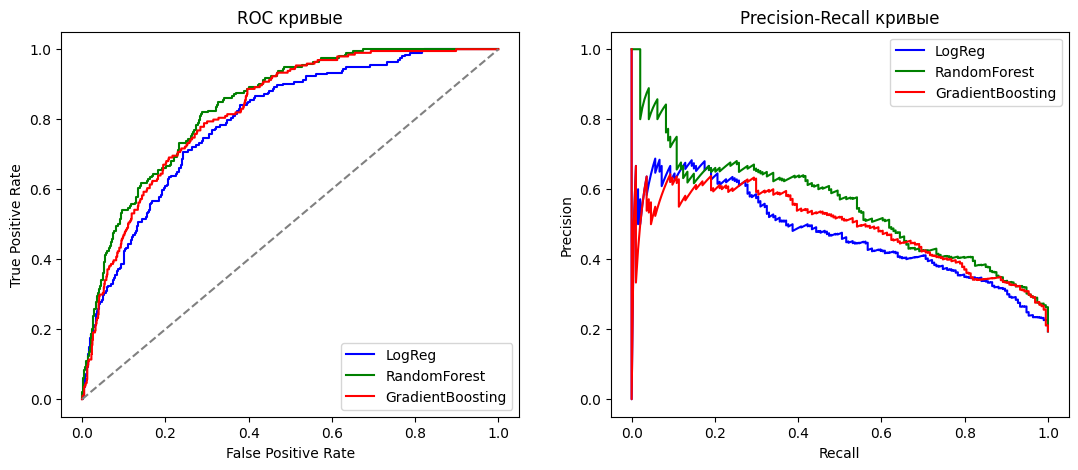

In [ ]:
colors_map = {'LogReg': 'blue', 'RandomForest': 'green', 'GradientBoosting': 'red'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, test_proba[name])
    axes[0].plot(fpr, tpr, label=name, color=colors_map[name])
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC кривые')
axes[0].legend()

for name in models:
    prec, rec, _ = precision_recall_curve(y_test, test_proba[name])
    axes[1].plot(rec, prec, label=name, color=colors_map[name])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall кривые')
axes[1].legend()

plt.savefig('images/roc_pr_curves.png')
plt.show()

### Confusion matrix для RandomForest

Лучшая модель по CV - RandomForest. Смотрим, какие ошибки она делает на тесте.

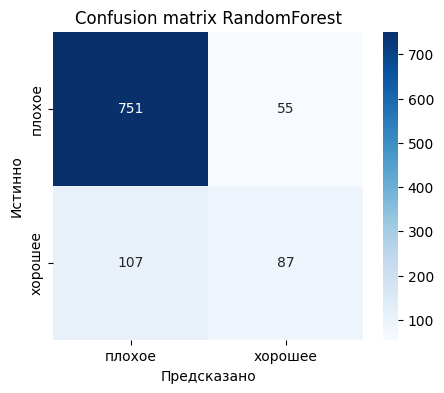

              precision    recall  f1-score   support

      плохое      0.875     0.932     0.903       806
     хорошее      0.613     0.448     0.518       194

    accuracy                          0.838      1000
   macro avg      0.744     0.690     0.710      1000
weighted avg      0.824     0.838     0.828      1000



In [ ]:
y_pred_rf = test_pred['RandomForest']
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['плохое', 'хорошее'], yticklabels=['плохое', 'хорошее'])
plt.xlabel('Предсказано')
plt.ylabel('Истинно')
plt.title('Confusion matrix RandomForest')
plt.savefig('images/confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=['плохое', 'хорошее'], digits=3))

## 5. Эксперименты с другими моделями

RF даёт ROC-AUC около 0.84. Проверим, можно ли получить лучше через градиентные бустинги: HistGBM из sklearn, LightGBM, XGBoost, CatBoost. Сравниваем в той же 5-фолдной CV.

In [ ]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
new_models = {
    'HistGBM': HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.05, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        scale_pos_weight=pos_weight, n_jobs=-1, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0
    ),
    'CatBoost': CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced', random_seed=RANDOM_STATE, verbose=False
    )
}

In [ ]:
cv_new_rows = []
for name, model in new_models.items():
    auc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    ap_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    cv_new_rows.append({
        'model': name,
        'roc_auc_mean': auc_scores.mean().round(4),
        'roc_auc_std': auc_scores.std().round(4),
        'pr_auc_mean': ap_scores.mean().round(4),
        'pr_auc_std': ap_scores.std().round(4)
    })
cv_new = pd.DataFrame(cv_new_rows).set_index('model')
cv_all = pd.concat([cv_results, cv_new]).sort_values('roc_auc_mean', ascending=False)
cv_all

,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
model,,,,
CatBoost,0.8513,0.0159,0.5768,0.0484
RandomForest,0.8509,0.0167,0.5901,0.0531
GradientBoosting,0.8434,0.0170,0.5576,0.0519
XGBoost,0.8423,0.0123,0.5569,0.0432
HistGBM,0.8421,0.0092,0.5621,0.0245
LightGBM,0.8405,0.0119,0.5645,0.0354
LogReg,0.8284,0.0167,0.5188,0.0389


Все семь моделей сходятся к ROC-AUC 0.84-0.85, разница меньше CV-разброса. Оставляем RandomForest как итоговую модель: лучший PR-AUC и удобная для интерпретации.

## 6. Важность признаков

Используем четыре метода и смотрим, согласуются ли они между собой.

1. Коэффициенты логистической регрессии - знак и сила линейного влияния
2. Impurity importance RF - доля сплитов по признаку
3. Permutation importance на test - падение ROC-AUC при перемешивании
4. SHAP - индивидуальный вклад признака в каждое предсказание

### 6.1 Коэффициенты логистической регрессии

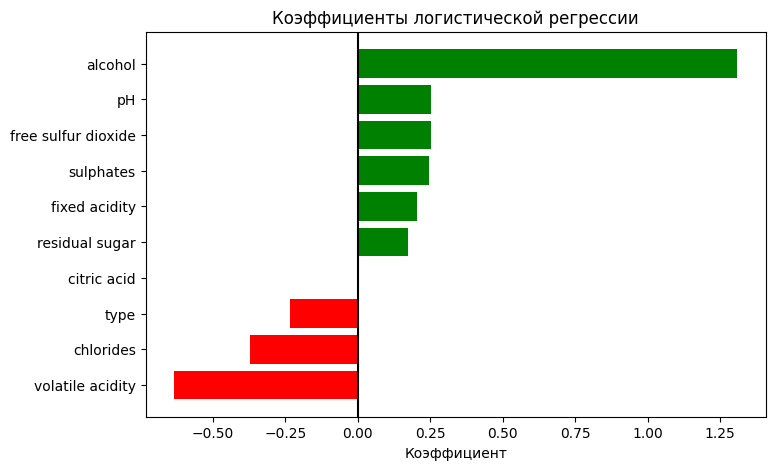

,coef
volatile acidity,-0.635
chlorides,-0.371
type,-0.233
citric acid,0.000
residual sugar,0.172
fixed acidity,0.202
sulphates,0.246
free sulfur dioxide,0.251
pH,0.252
alcohol,1.309


In [ ]:
logreg_coefs = pd.Series(
    fitted_models['LogReg'].coef_[0], index=feature_cols
).sort_values()
coef_colors = ['red' if v < 0 else 'green' for v in logreg_coefs.values]

plt.figure(figsize=(8, 5))
plt.barh(logreg_coefs.index, logreg_coefs.values, color=coef_colors)
plt.axvline(0, color='black')
plt.xlabel('Коэффициент')
plt.title('Коэффициенты логистической регрессии')
plt.savefig('images/logreg_coefs.png')
plt.show()

logreg_coefs.to_frame('coef').round(3)

### 6.2 Impurity importance и permutation importance RandomForest

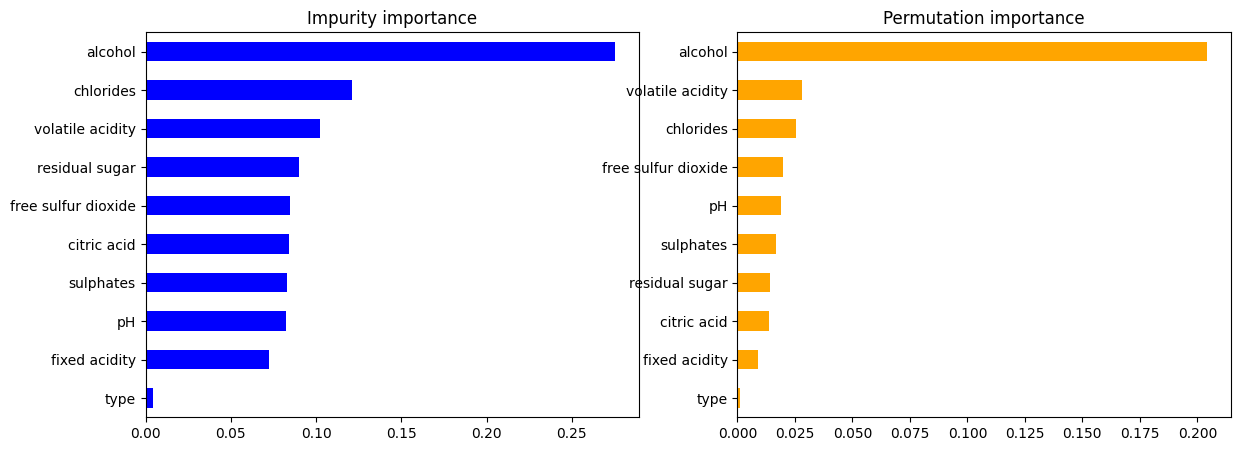

,impurity,permutation
alcohol,0.2755,0.2042
volatile acidity,0.1026,0.0280
chlorides,0.1210,0.0256
free sulfur dioxide,0.0849,0.0197
pH,0.0825,0.0189
sulphates,0.0827,0.0167
residual sugar,0.0902,0.0143
citric acid,0.0838,0.0139
fixed acidity,0.0724,0.0090
type,0.0042,0.0012


In [ ]:
rf_model = fitted_models['RandomForest']
rf_impurity = pd.Series(rf_model.feature_importances_, index=feature_cols)
perm = permutation_importance(
    rf_model, X_test_scaled, y_test,
    scoring='roc_auc', n_repeats=10, n_jobs=-1, random_state=RANDOM_STATE
)
rf_permutation = pd.Series(perm.importances_mean, index=feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rf_impurity.sort_values().plot.barh(ax=axes[0], color='blue')
axes[0].set_title('Impurity importance')
rf_permutation.sort_values().plot.barh(ax=axes[1], color='orange')
axes[1].set_title('Permutation importance')
plt.savefig('images/rf_importance.png')
plt.show()

pd.DataFrame({
    'impurity': rf_impurity,
    'permutation': rf_permutation
}).sort_values('permutation', ascending=False).round(4)

### 6.3 SHAP values

SHAP раскладывает каждое предсказание модели на вклады отдельных признаков. Даёт силу, направление и форму зависимости.

In [ ]:
explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_test_scaled)
if isinstance(shap_values_raw, list):
    shap_values_pos = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_values_pos = shap_values_raw[:, :, 1]
else:
    shap_values_pos = shap_values_raw

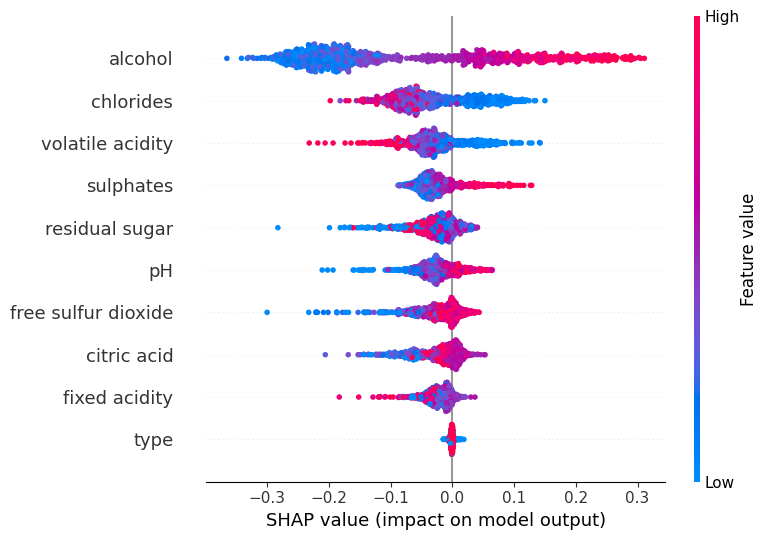

In [ ]:
shap.summary_plot(shap_values_pos, X_test_scaled, feature_names=feature_cols, show=False)
plt.savefig('images/shap_summary.png')
plt.show()

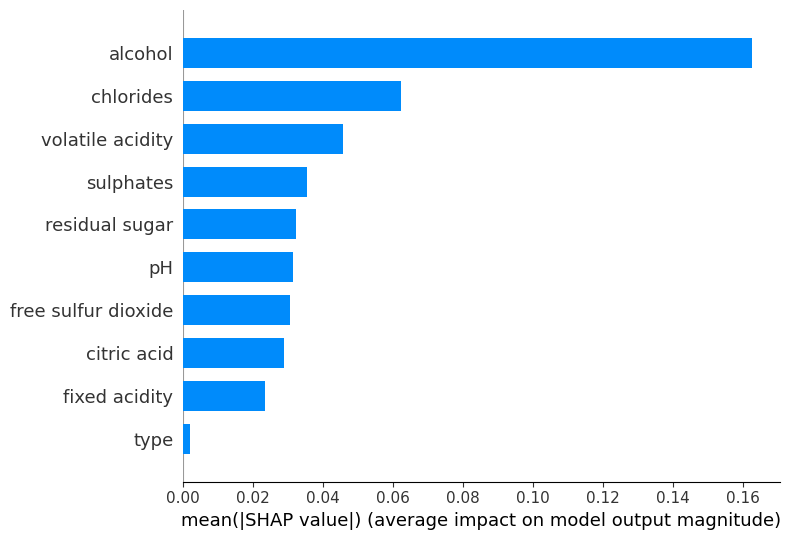

In [ ]:
shap.summary_plot(shap_values_pos, X_test_scaled, feature_names=feature_cols, plot_type='bar', show=False)
plt.savefig('images/shap_bar.png')
plt.show()

### 6.4 Сводная таблица важности

Объединяем четыре источника. Средний ранг показывает консолидированную важность.

In [ ]:
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
mean_signed_shap = shap_values_pos.mean(axis=0)

importance_summary = pd.DataFrame({
    'logreg_coef': fitted_models['LogReg'].coef_[0],
    'rf_impurity': rf_impurity.values,
    'rf_permutation': rf_permutation.values,
    'shap_mean_abs': mean_abs_shap,
    'shap_mean_signed': mean_signed_shap
}, index=feature_cols)
importance_summary['rank_logreg'] = importance_summary['logreg_coef'].abs().rank(ascending=False).astype(int)
importance_summary['rank_impurity'] = importance_summary['rf_impurity'].rank(ascending=False).astype(int)
importance_summary['rank_permutation'] = importance_summary['rf_permutation'].rank(ascending=False).astype(int)
importance_summary['rank_shap'] = importance_summary['shap_mean_abs'].rank(ascending=False).astype(int)
importance_summary['mean_rank'] = importance_summary[
    ['rank_logreg', 'rank_impurity', 'rank_permutation', 'rank_shap']
].mean(axis=1).round(2)
importance_summary = importance_summary.sort_values('mean_rank')
importance_summary.to_csv('feature_importance_summary.csv')
importance_summary.round(4)

,logreg_coef,rf_impurity,rf_permutation,shap_mean_abs,shap_mean_signed,rank_logreg,rank_impurity,rank_permutation,rank_shap,mean_rank
alcohol,1.3092,0.2755,0.2042,0.1625,-0.0722,1,1,1,1,1.00
volatile acidity,-0.6348,0.1026,0.0280,0.0456,-0.0271,2,3,2,3,2.50
chlorides,-0.3713,0.1210,0.0256,0.0623,-0.0291,3,2,3,2,2.50
free sulfur dioxide,0.2508,0.0849,0.0197,0.0306,-0.0251,5,5,4,7,5.25
pH,0.2518,0.0825,0.0189,0.0315,-0.0240,4,8,5,6,5.75
sulphates,0.2460,0.0827,0.0167,0.0354,-0.0227,6,7,6,4,5.75
residual sugar,0.1724,0.0902,0.0143,0.0324,-0.0276,9,4,7,5,6.25
citric acid,0.0002,0.0838,0.0139,0.0288,-0.0224,10,6,8,8,8.00
fixed acidity,0.2024,0.0724,0.0090,0.0233,-0.0222,8,9,9,9,8.75
type,-0.2328,0.0042,0.0012,0.0019,-0.0008,7,10,10,10,9.25


### 6.5 Финальный график

Bar chart по средней силе SHAP, цвет - знак из LogReg (зелёный повышает качество, красный понижает).

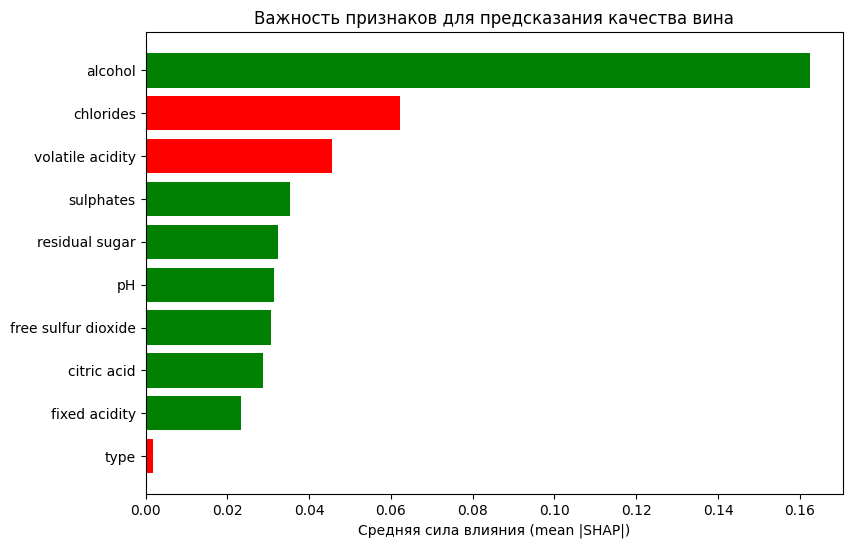

In [ ]:
final = importance_summary[['shap_mean_abs', 'logreg_coef']].copy()
final = final.sort_values('shap_mean_abs', ascending=True)
final_colors = ['green' if c > 0 else 'red' for c in final['logreg_coef'].values]

plt.figure(figsize=(9, 6))
plt.barh(final.index, final['shap_mean_abs'].values, color=final_colors)
plt.xlabel('Средняя сила влияния (mean |SHAP|)')
plt.title('Важность признаков для предсказания качества вина')
plt.savefig('images/final_importance.png')
plt.show()

## 7. Эксперимент с feature engineering

Проверим, можно ли пробить потолок 0.84 ROC-AUC за счёт инженерных признаков: взаимодействий, отношений, полиномов. Итого 10 -> 19 признаков.

In [ ]:
wine_eng = wine_new.copy()
wine_eng['alc_vol'] = wine_eng['alcohol'] * wine_eng['volatile acidity']
wine_eng['alc_sugar'] = wine_eng['alcohol'] * wine_eng['residual sugar']
wine_eng['alc_chlor'] = wine_eng['alcohol'] * wine_eng['chlorides']
wine_eng['sulph_alc'] = wine_eng['sulphates'] * wine_eng['alcohol']
wine_eng['acid_total'] = wine_eng['fixed acidity'] + wine_eng['volatile acidity']
wine_eng['alc_per_sugar'] = wine_eng['alcohol'] / (wine_eng['residual sugar'].abs() + 1)
wine_eng['so2_ph'] = wine_eng['free sulfur dioxide'] * wine_eng['pH']
wine_eng['alcohol_sq'] = wine_eng['alcohol'] ** 2
wine_eng['vol_acid_sq'] = wine_eng['volatile acidity'] ** 2

feature_cols_eng = feature_cols + [
    'alc_vol', 'alc_sugar', 'alc_chlor', 'sulph_alc',
    'acid_total', 'alc_per_sugar', 'so2_ph',
    'alcohol_sq', 'vol_acid_sq'
]
print('Признаков было:', len(feature_cols))
print('Признаков стало:', len(feature_cols_eng))

Признаков было: 10
Признаков стало: 19


In [ ]:
X_eng = wine_eng[feature_cols_eng].copy()
y_eng = wine_eng['is_good'].copy()
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, stratify=y_eng, random_state=RANDOM_STATE
)
scaler_eng = StandardScaler()
X_train_eng_scaled = pd.DataFrame(scaler_eng.fit_transform(X_train_eng), columns=feature_cols_eng, index=X_train_eng.index)
X_test_eng_scaled = pd.DataFrame(scaler_eng.transform(X_test_eng), columns=feature_cols_eng, index=X_test_eng.index)

eng_candidates = {
    'RF_eng': RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'CatBoost_eng': CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced', random_seed=RANDOM_STATE, verbose=False
    ),
    'LightGBM_eng': lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.05, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    )
}
eng_rows = []
for name, model in eng_candidates.items():
    auc_scores = cross_val_score(model, X_train_eng_scaled, y_train_eng, cv=cv, scoring='roc_auc', n_jobs=-1)
    ap_scores = cross_val_score(model, X_train_eng_scaled, y_train_eng, cv=cv, scoring='average_precision', n_jobs=-1)
    eng_rows.append({
        'model': name,
        'roc_auc_mean': auc_scores.mean().round(4),
        'roc_auc_std': auc_scores.std().round(4),
        'pr_auc_mean': ap_scores.mean().round(4),
        'pr_auc_std': ap_scores.std().round(4)
    })
eng_results = pd.DataFrame(eng_rows).set_index('model')
baseline_rf = cv_results.loc[['RandomForest']].copy()
baseline_rf.index = ['RF_baseline']
comparison = pd.concat([baseline_rf, eng_results])
display(comparison)
print('Лучшая базовая ROC-AUC:', cv_results['roc_auc_mean'].max())
print('Лучшая с инженерными признаками:', eng_results['roc_auc_mean'].max())

,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
RF_baseline,0.8509,0.0167,0.5901,0.0531
RF_eng,0.8485,0.0183,0.5871,0.0580
CatBoost_eng,0.8498,0.0182,0.5656,0.0557
LightGBM_eng,0.8435,0.0161,0.5605,0.0499


Лучшая базовая ROC-AUC: 0.8509
Лучшая с инженерными признаками: 0.8498


Прирост -0.001 ROC-AUC, в пределах CV-разброса. Инженерные признаки не помогли: RF и бустинги уже улавливают эти взаимодействия через сплиты.

Это третье подтверждение того, что 0.84 - это потолок данных, а не слабость модели. Финальная модель - RandomForest на 10 базовых признаках.

## 8. Итоги

Часть 4 отвечает на главный вопрос проекта и на доп. вопрос про отделимость хорошего вина от плохого.

### Какие химические свойства определяют качество вина

Все четыре метода важности (LogReg, impurity, permutation, SHAP) согласованно дали один и тот же топ-3:

1. alcohol - повышает качество, самый сильный предиктор (ранг 1 во всех методах, mean |SHAP| в 2.6 раза больше следующего признака)
2. volatile acidity - понижает (уксусный привкус)
3. chlorides - понижают (солёность)

Sulphates, pH, free sulfur dioxide и residual sugar дают слабый положительный вклад. Citric acid, fixed acidity и type практически не влияют. Низкая важность type означает, что модель не использует различие red/white - те же химические признаки работают одинаково для обоих типов.

### Можно ли заранее отделить хорошее вино от плохого

Можно, но не идеально. Финальная модель RandomForest на отложенной выборке:

- ROC-AUC = 0.85
- PR-AUC = 0.554 при базовой доле 0.194
- На пороге 0.5: precision = 0.61, recall = 0.45 для класса хороших

Модель надёжно ранжирует вина по вероятности качества. Порог классификации можно сместить под бизнес-задачу.